Fitting LSMC model...
Computing example action at initial state...
Best action at t=0: [0.35 0.2  0.25 0.2 ]
Estimated value: 0.47548601786295575
Simulating learned policy...
Mean terminal wealth: 1.4544005750676716
Std terminal wealth: 0.20581047897005392
Mean terminal utility: 0.4704232297018254


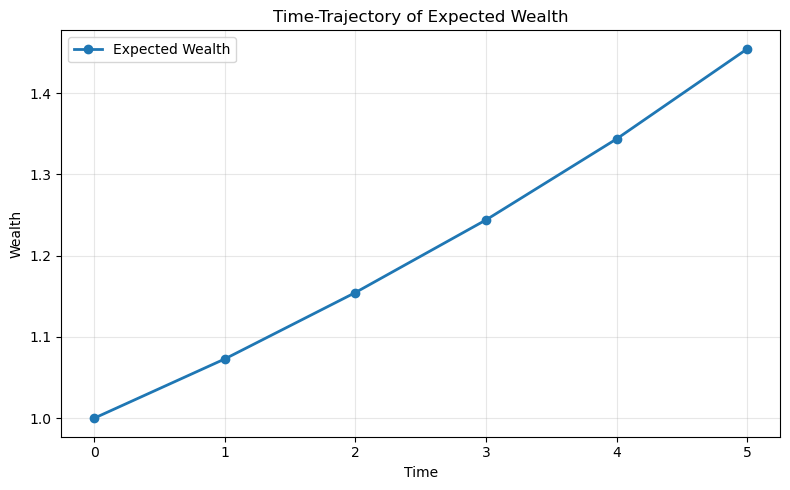

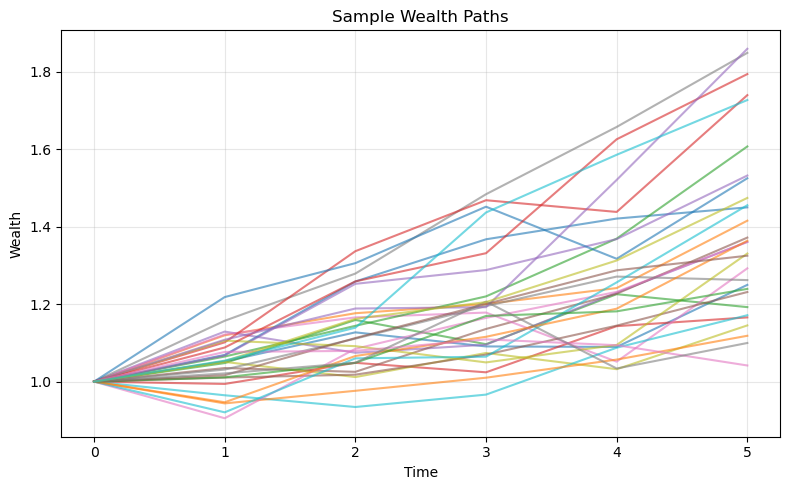

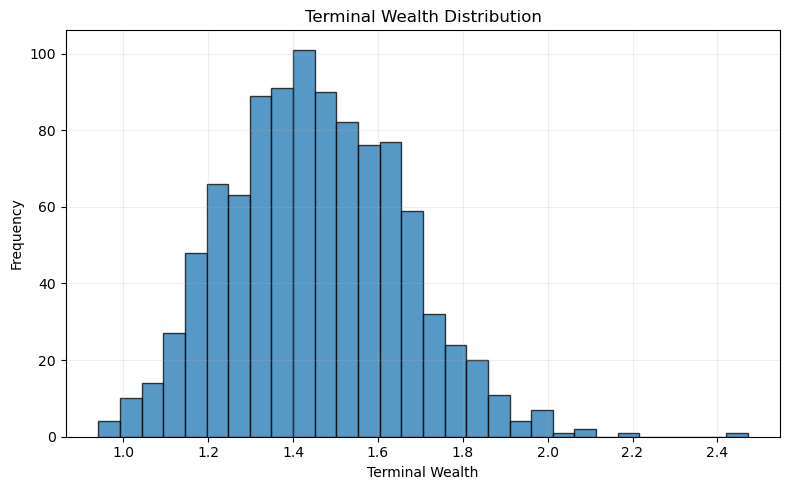

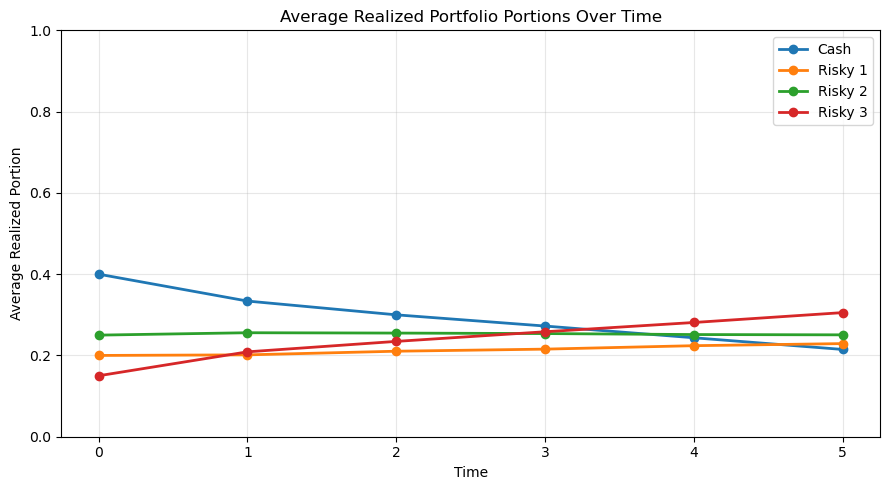

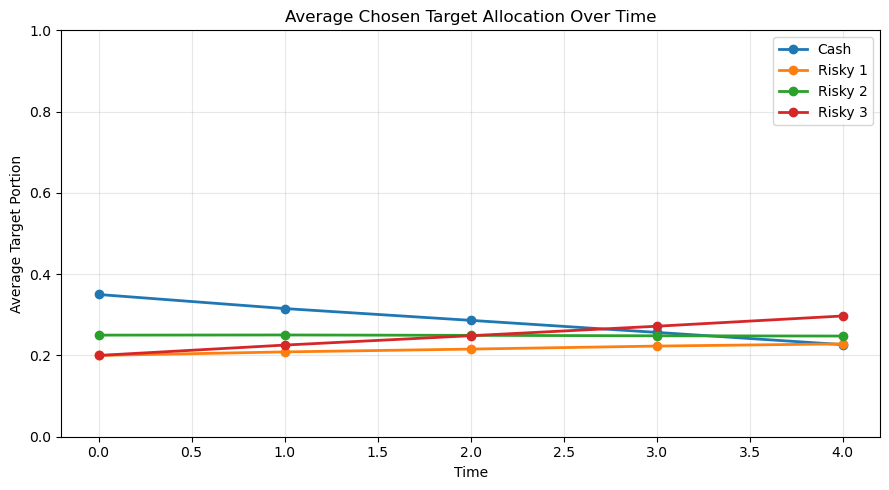

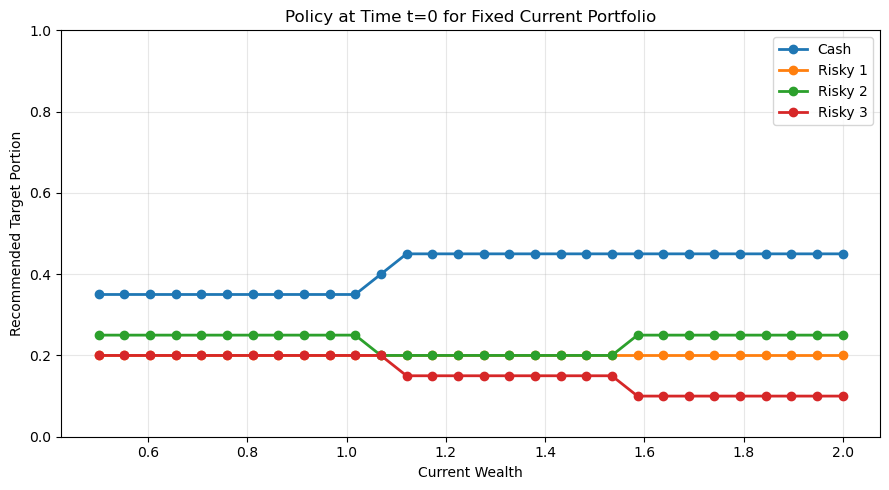

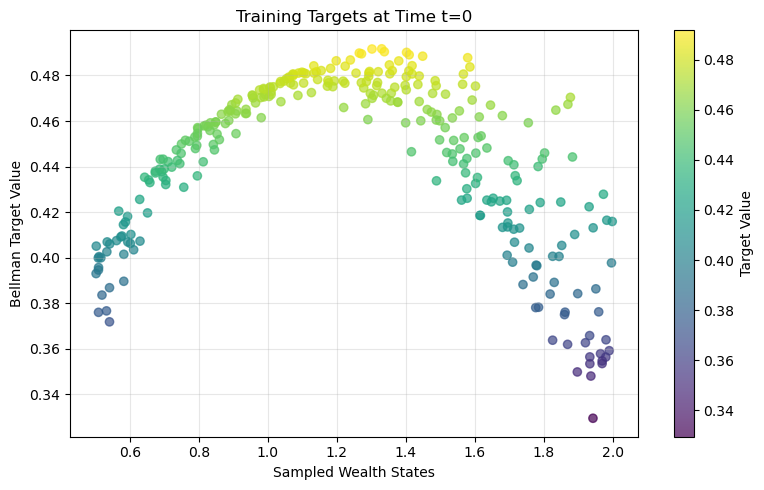

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression


# ============================================================
# 1. Utility
# ============================================================

def cara_utility(w, risk_aversion=2.0):
    """
    CARA utility:
        U(w) = (1 - exp(-lambda * w)) / lambda
    """
    w = np.asarray(w, dtype=float)
    return (1.0 - np.exp(-risk_aversion * w)) / risk_aversion


# ============================================================
# 2. Value function approximator for LSMC
# ============================================================

class PolynomialValueFunction:
    """
    Approximate continuation/value function with polynomial regression.

    State features are:
        [W, p_0, p_1, ..., p_n]
    where p_0 is cash portion and p_1,...,p_n are risky portions.
    """
    def __init__(self, degree=2):
        self.degree = degree
        self.poly = PolynomialFeatures(degree=degree, include_bias=True)
        self.model = LinearRegression()

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        X_poly = self.poly.fit_transform(X)
        self.model.fit(X_poly, y)

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        X_poly = self.poly.transform(X)
        return self.model.predict(X_poly)


# ============================================================
# 3. Action grid generator under adjustment constraint
# ============================================================

def generate_portfolio_grid(n_assets_total, step=0.05):
    """
    Generate all portfolio weights on simplex:
        p_i >= 0, sum_i p_i = 1

    Returns array of shape (K, n_assets_total).
    """
    m = int(round(1.0 / step))
    grid = []

    def helper(prefix, remaining, k_left):
        if k_left == 1:
            grid.append(prefix + [remaining / m])
            return
        for i in range(remaining + 1):
            helper(prefix + [i / m], remaining - i, k_left - 1)

    helper([], m, n_assets_total)
    return np.array(grid, dtype=float)


# ============================================================
# 4. LSMC solver for assignment
# ============================================================

class LSMCMultiAssetCARA:
    """
    Multi-asset LSMC solver for the assignment.

    Assets:
        asset 0: cash
        asset 1..n: risky assets

    Input:
        a_means[k] : mean return of risky asset k
        s_vars[k]  : variance of risky asset k
        p_init     : initial portions including cash, shape (n+1,)
                     p_init[0] = cash portion
        r          : risk-free return on cash
        max_adjust : max L1 rebalancing amount per period, e.g. 0.10

    State:
        (W_t, p_t)
    Action:
        choose new target portfolio u_t satisfying:
            u_t >= 0, sum(u_t)=1,
            sum_i |u_t[i] - p_t[i]| <= max_adjust
    Transition:
        after rebalancing to u_t, returns realize.
    Terminal objective:
        maximize E[ U(W_T) ] under CARA utility.
    """

    def __init__(
        self,
        T,
        a_means,
        s_vars,
        p_init,
        r=0.02,
        risk_aversion=2.0,
        max_adjust=0.10,
        grid_step=0.05,
        poly_degree=2,
        n_state_samples=400,
        n_mc_samples=300,
        wealth_min=0.5,
        wealth_max=2.0,
        random_state=42,
    ):
        self.T = int(T)
        self.a_means = np.asarray(a_means, dtype=float)   # risky only, length n
        self.s_vars = np.asarray(s_vars, dtype=float)     # risky only, length n
        self.s_stds = np.sqrt(self.s_vars)
        self.n_risky = len(a_means)
        self.n_total = self.n_risky + 1  # include cash

        self.p_init = np.asarray(p_init, dtype=float)
        self.r = float(r)
        self.risk_aversion = float(risk_aversion)
        self.max_adjust = float(max_adjust)
        self.grid_step = float(grid_step)
        self.poly_degree = int(poly_degree)
        self.n_state_samples = int(n_state_samples)
        self.n_mc_samples = int(n_mc_samples)
        self.wealth_min = float(wealth_min)
        self.wealth_max = float(wealth_max)
        self.rng = np.random.default_rng(random_state)

        if self.T >= 10:
            raise ValueError("Assignment requires time horizon < 10.")
        if self.n_risky >= 5:
            raise ValueError("Assignment requires n < 5 risky assets.")
        if len(self.p_init) != self.n_total:
            raise ValueError("p_init must have length n+1 including cash.")
        if not np.isclose(self.p_init.sum(), 1.0):
            raise ValueError("Initial portfolio portions must sum to 1.")
        if np.any(self.p_init < 0):
            raise ValueError("Portfolio portions must be nonnegative.")

        # Full portfolio simplex grid
        self.portfolio_grid = generate_portfolio_grid(self.n_total, step=self.grid_step)

        # Fitted value models V_t
        self.value_models = [None] * (self.T + 1)

        # Policy storage
        self.policy_data = {}

    # --------------------------------------------------------
    # utility
    # --------------------------------------------------------
    def utility(self, w):
        return cara_utility(w, risk_aversion=self.risk_aversion)

    # --------------------------------------------------------
    # returns sampling
    # --------------------------------------------------------
    def sample_risky_returns(self, n_samples):
        """
        Sample risky returns independently:
            R_k ~ N(a_k, s_k)
        returns shape: (n_samples, n_risky)
        """
        return self.rng.normal(
            loc=self.a_means,
            scale=self.s_stds,
            size=(n_samples, self.n_risky)
        )

    # --------------------------------------------------------
    # action feasibility
    # --------------------------------------------------------
    def feasible_actions(self, current_portion):
        """
        Return all target portfolios u satisfying:
            sum_i |u_i - current_portion_i| <= max_adjust
        """
        current_portion = np.asarray(current_portion, dtype=float)
        l1_dist = np.sum(np.abs(self.portfolio_grid - current_portion), axis=1)
        feasible_idx = np.where(l1_dist <= self.max_adjust + 1e-12)[0]
        return self.portfolio_grid[feasible_idx]

    # --------------------------------------------------------
    # transition
    # --------------------------------------------------------
    def next_state(self, W, target_portion, risky_returns):
        """
        Given:
            W              : scalar current wealth
            target_portion : shape (n+1,), including cash
            risky_returns  : shape (..., n_risky)

        Returns:
            W_next         : shape (...)
            p_next         : shape (..., n+1)

        Cash gross return: 1 + r
        Risky asset gross return: 1 + R_k
        """
        target_portion = np.asarray(target_portion, dtype=float)
        risky_returns = np.asarray(risky_returns, dtype=float)

        cash_weight = target_portion[0]
        risky_weights = target_portion[1:]

        cash_gross = 1.0 + self.r
        risky_gross = 1.0 + risky_returns

        G = cash_weight * cash_gross + np.sum(risky_weights * risky_gross, axis=-1)

        G = np.maximum(G, 1e-12)
        W_next = W * G

        cash_next = (cash_weight * cash_gross) / G
        risky_next = (risky_weights * risky_gross) / G[..., None]

        p_next = np.concatenate([cash_next[..., None], risky_next], axis=-1)
        return W_next, p_next

    # --------------------------------------------------------
    # state feature construction
    # --------------------------------------------------------
    def make_state_features(self, W, p):
        """
        Build regression features [W, p_0, ..., p_n]
        """
        W = np.asarray(W, dtype=float)

        if W.ndim == 0:
            W = W.reshape(1)

        p = np.asarray(p, dtype=float)
        if p.ndim == 1:
            p = np.tile(p, (len(W), 1))

        return np.column_stack([W, p])

    # --------------------------------------------------------
    # random state sampling for backward induction
    # --------------------------------------------------------
    def sample_states(self, n_samples):
        """
        Sample states (W, p) for regression at each time step.
        Wealth sampled uniformly from [wealth_min, wealth_max].
        Portion sampled from simplex grid.
        """
        W_samples = self.rng.uniform(self.wealth_min, self.wealth_max, size=n_samples)
        idx = self.rng.integers(0, len(self.portfolio_grid), size=n_samples)
        p_samples = self.portfolio_grid[idx]
        return W_samples, p_samples

    # --------------------------------------------------------
    # fit with LSMC backward induction
    # --------------------------------------------------------
    def fit(self):
        """
        Backward induction with LSMC:
        1. Terminal: V_T(W,p) = U(W)
        2. For t = T-1,...,0:
            - sample states (W,p)
            - for each state, enumerate feasible actions
            - for each action, estimate continuation value by MC
            - choose maximizing action
            - regress V_t on state features
        """
        terminal_model = PolynomialValueFunction(degree=self.poly_degree)

        W_term, p_term = self.sample_states(max(1000, self.n_state_samples))
        X_term = self.make_state_features(W_term, p_term)
        y_term = self.utility(W_term)
        terminal_model.fit(X_term, y_term)
        self.value_models[self.T] = terminal_model

        for t in range(self.T - 1, -1, -1):
            W_states, p_states = self.sample_states(self.n_state_samples)

            V_targets = np.zeros(self.n_state_samples)
            best_actions = np.zeros((self.n_state_samples, self.n_total))

            returns_mc = self.sample_risky_returns(self.n_mc_samples)

            for i in range(self.n_state_samples):
                W = W_states[i]
                p = p_states[i]

                feasible = self.feasible_actions(p)
                q_values = np.zeros(len(feasible))

                for a_idx, u in enumerate(feasible):
                    W_next, p_next = self.next_state(W, u, returns_mc)
                    X_next = self.make_state_features(W_next, p_next)
                    continuation = self.value_models[t + 1].predict(X_next)
                    q_values[a_idx] = np.mean(continuation)

                best_idx = int(np.argmax(q_values))
                V_targets[i] = q_values[best_idx]
                best_actions[i] = feasible[best_idx]

            X_states = self.make_state_features(W_states, p_states)
            model_t = PolynomialValueFunction(degree=self.poly_degree)
            model_t.fit(X_states, V_targets)
            self.value_models[t] = model_t

            self.policy_data[t] = {
                "W_states": W_states,
                "p_states": p_states,
                "best_actions": best_actions,
                "V_targets": V_targets,
            }

    # --------------------------------------------------------
    # policy evaluation / one-step lookahead
    # --------------------------------------------------------
    def get_action(self, t, W, p):
        """
        One-step lookahead policy from fitted V_{t+1}.
        Returns:
            best_target_portion, estimated_value
        """
        if t >= self.T:
            raise ValueError("No action at terminal time.")

        feasible = self.feasible_actions(p)
        returns_mc = self.sample_risky_returns(self.n_mc_samples)
        q_values = np.zeros(len(feasible))

        for a_idx, u in enumerate(feasible):
            W_next, p_next = self.next_state(W, u, returns_mc)
            X_next = self.make_state_features(W_next, p_next)
            continuation = self.value_models[t + 1].predict(X_next)
            q_values[a_idx] = np.mean(continuation)

        best_idx = int(np.argmax(q_values))
        return feasible[best_idx], q_values[best_idx]

    # --------------------------------------------------------
    # simulation under learned policy
    # --------------------------------------------------------
    def simulate_policy(self, W0=1.0, p0=None, n_paths=1000):
        """
        Simulate the learned policy out-of-sample.
        """
        if p0 is None:
            p0 = self.p_init

        wealth_paths = np.zeros((n_paths, self.T + 1))
        portion_paths = np.zeros((n_paths, self.T + 1, self.n_total))
        action_paths = np.zeros((n_paths, self.T, self.n_total))

        wealth_paths[:, 0] = W0
        portion_paths[:, 0, :] = p0

        for path in range(n_paths):
            W = W0
            p = p0.copy()

            for t in range(self.T):
                u, _ = self.get_action(t, W, p)
                action_paths[path, t, :] = u

                R = self.sample_risky_returns(1)
                W, p = self.next_state(W, u, R)
                W = float(W[0])
                p = p[0]

                wealth_paths[path, t + 1] = W
                portion_paths[path, t + 1, :] = p

        terminal_wealth = wealth_paths[:, -1]
        terminal_utility = self.utility(terminal_wealth)

        return {
            "wealth_paths": wealth_paths,
            "portion_paths": portion_paths,
            "action_paths": action_paths,
            "terminal_wealth": terminal_wealth,
            "terminal_utility": terminal_utility,
            "mean_terminal_wealth": np.mean(terminal_wealth),
            "std_terminal_wealth": np.std(terminal_wealth),
            "mean_terminal_utility": np.mean(terminal_utility),
        }

    # ========================================================
    # 5. Plot functions
    # ========================================================

    def plot_expected_wealth_trajectory(self, sim_result):
        """
        Plot average wealth over time.
        """
        mean_path = sim_result["wealth_paths"].mean(axis=0)

        plt.figure(figsize=(8, 5))
        plt.plot(range(self.T + 1), mean_path, marker="o", linewidth=2, label="Expected Wealth")
        plt.xlabel("Time")
        plt.ylabel("Wealth")
        plt.title("Time-Trajectory of Expected Wealth")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_sample_wealth_paths(self, sim_result, n_plot=30):
        """
        Plot a subset of wealth sample paths.
        """
        paths = sim_result["wealth_paths"]
        n_plot = min(n_plot, paths.shape[0])

        plt.figure(figsize=(8, 5))
        for i in range(n_plot):
            plt.plot(range(self.T + 1), paths[i], alpha=0.6)
        plt.xlabel("Time")
        plt.ylabel("Wealth")
        plt.title("Sample Wealth Paths")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_terminal_wealth_histogram(self, sim_result, bins=30):
        """
        Histogram of terminal wealth.
        """
        terminal_wealth = sim_result["terminal_wealth"]

        plt.figure(figsize=(8, 5))
        plt.hist(terminal_wealth, bins=bins, alpha=0.75, edgecolor="black")
        plt.xlabel("Terminal Wealth")
        plt.ylabel("Frequency")
        plt.title("Terminal Wealth Distribution")
        plt.grid(True, alpha=0.2)
        plt.tight_layout()
        plt.show()

    def plot_average_portions_over_time(self, sim_result):
        """
        Plot average realized portfolio portions over time.
        Includes cash and all risky assets.
        """
        portion_paths = sim_result["portion_paths"]
        mean_portions = portion_paths.mean(axis=0)  # shape (T+1, n_total)

        plt.figure(figsize=(9, 5))
        labels = ["Cash"] + [f"Risky {k}" for k in range(1, self.n_total)]

        for j in range(self.n_total):
            plt.plot(range(self.T + 1), mean_portions[:, j], marker="o", linewidth=2, label=labels[j])

        plt.xlabel("Time")
        plt.ylabel("Average Realized Portion")
        plt.title("Average Realized Portfolio Portions Over Time")
        plt.ylim(0, 1)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_average_actions_over_time(self, sim_result):
        """
        Plot average chosen target allocations over time.
        """
        action_paths = sim_result["action_paths"]
        mean_actions = action_paths.mean(axis=0)  # shape (T, n_total)

        plt.figure(figsize=(9, 5))
        labels = ["Cash"] + [f"Risky {k}" for k in range(1, self.n_total)]

        for j in range(self.n_total):
            plt.plot(range(self.T), mean_actions[:, j], marker="o", linewidth=2, label=labels[j])

        plt.xlabel("Time")
        plt.ylabel("Average Target Portion")
        plt.title("Average Chosen Target Allocation Over Time")
        plt.ylim(0, 1)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_policy_for_fixed_portfolio(self, t, fixed_portion=None, wealth_grid=None):
        """
        For a fixed current portfolio portion p, plot the recommended action
        as a function of current wealth W.

        Since action depends on both W and p, we fix p and vary W.
        """
        if fixed_portion is None:
            fixed_portion = self.p_init
        fixed_portion = np.asarray(fixed_portion, dtype=float)

        if wealth_grid is None:
            wealth_grid = np.linspace(self.wealth_min, self.wealth_max, 30)

        chosen_actions = np.zeros((len(wealth_grid), self.n_total))

        for i, W in enumerate(wealth_grid):
            u, _ = self.get_action(t, W, fixed_portion)
            chosen_actions[i] = u

        plt.figure(figsize=(9, 5))
        labels = ["Cash"] + [f"Risky {k}" for k in range(1, self.n_total)]

        for j in range(self.n_total):
            plt.plot(wealth_grid, chosen_actions[:, j], marker="o", linewidth=2, label=labels[j])

        plt.xlabel("Current Wealth")
        plt.ylabel("Recommended Target Portion")
        plt.title(f"Policy at Time t={t} for Fixed Current Portfolio")
        plt.ylim(0, 1)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_training_value_scatter(self, t):
        """
        Scatter plot of sampled states vs fitted value targets at time t.
        For visualization, use wealth on x-axis and color by target value.
        """
        if t not in self.policy_data:
            raise ValueError(f"No stored training data for time {t}.")

        W_states = self.policy_data[t]["W_states"]
        V_targets = self.policy_data[t]["V_targets"]

        plt.figure(figsize=(8, 5))
        sc = plt.scatter(W_states, V_targets, c=V_targets, cmap="viridis", alpha=0.7)
        plt.xlabel("Sampled Wealth States")
        plt.ylabel("Bellman Target Value")
        plt.title(f"Training Targets at Time t={t}")
        plt.colorbar(sc, label="Target Value")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


# ============================================================
# 6. Example usage
# ============================================================

if __name__ == "__main__":
    model = LSMCMultiAssetCARA(
        T=5,   # time horizon < 10
        a_means=[0.08, 0.10, 0.12],         # 3 risky assets => n=3 < 5
        s_vars=[0.02, 0.03, 0.025],
        p_init=[0.40, 0.20, 0.25, 0.15],    # cash + 3 risky, sum = 1
        r=0.02,
        risk_aversion=2.0,
        max_adjust=0.10,
        grid_step=0.05,
        poly_degree=2,
        n_state_samples=300,
        n_mc_samples=300,
        wealth_min=0.5,
        wealth_max=2.0,
        random_state=42,
    )

    print("Fitting LSMC model...")
    model.fit()

    print("Computing example action at initial state...")
    best_action, est_value = model.get_action(0, W=1.0, p=np.array([0.40, 0.20, 0.25, 0.15]))
    print("Best action at t=0:", best_action)
    print("Estimated value:", est_value)

    print("Simulating learned policy...")
    sim = model.simulate_policy(W0=1.0, p0=np.array([0.40, 0.20, 0.25, 0.15]), n_paths=1000)

    print("Mean terminal wealth:", sim["mean_terminal_wealth"])
    print("Std terminal wealth:", sim["std_terminal_wealth"])
    print("Mean terminal utility:", sim["mean_terminal_utility"])

    # -------------------------------
    # Plot results
    # -------------------------------
    model.plot_expected_wealth_trajectory(sim)
    model.plot_sample_wealth_paths(sim, n_plot=30)
    model.plot_terminal_wealth_histogram(sim, bins=30)
    model.plot_average_portions_over_time(sim)
    model.plot_average_actions_over_time(sim)
    model.plot_policy_for_fixed_portfolio(t=0, fixed_portion=np.array([0.40, 0.20, 0.25, 0.15]))
    model.plot_training_value_scatter(t=0)